<a href="https://colab.research.google.com/github/farrelrassya/scikit-learn-cookbook/blob/main/13.%20Deploying%20Models%20in%20Production%20/%20Ch13_Deploying_sklearn_Models_in_Production.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 13: Deploying scikit-learn Models in Production

Everything we have covered in previous chapters -- data preprocessing, model training, cross-validation, hyperparameter tuning -- is of little use in the business world if the model just sits on your laptop. Models must be **deployed** in compute environments that allow for scalability and high throughput while maintaining predictive performance at or above the business rules that govern them.

Although we devote a single chapter to this topic, production ML deployment, monitoring, benchmarking, and the continuous integration/continuous deployment/continuous training (**CI/CD/CT**) cycle make up the lion's share of real-world challenges. Many considerations are non-technical: how do I determine how well a model needs to perform to achieve a given ROI? When do I need to retrain? Do I need different models for different customer segments or geographic regions? These questions would require several more textbooks -- so we keep things focused on the scikit-learn ecosystem.

**What we will cover:**

1. Overview of model deployment (packaging and serving predictions)
2. Serialization and persistence techniques (pickle vs. joblib)
3. Scaling models for production (batch serving, parallelism)
4. Monitoring and updating deployed models (drift detection, incremental learning)
5. Managing the model life cycle (versioning, metadata, reproducibility)
6. Setting up deployment pipelines (end-to-end CI/CD with scikit-learn `Pipeline`)

## Setup

All code in this chapter runs on Google Colab's default environment without additional installations. We rely on scikit-learn's built-in serialization tools (`joblib`), standard library modules (`pickle`, `json`, `time`), and `matplotlib` for monitoring visualizations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

import sklearn
print(f"scikit-learn version: {sklearn.__version__}")
print(f"NumPy version: {np.__version__}")
print("Setup complete.")

scikit-learn version: 1.6.1
NumPy version: 2.0.2
Setup complete.


## 13.1 Overview of Model Deployment

Deploying a model means moving it from your development environment into production so that real users or systems can access its predictions. Deployment involves three core steps: preparing a reliable **artifact** (the serialized model), **serving** it with appropriate latency and throughput, and **ensuring** that it continues to perform well as the data evolves.

The simplest deployment pattern for scikit-learn models uses `joblib` to serialize the trained estimator to disk. This artifact can then be loaded in any Python environment with the same scikit-learn version installed, restoring the model's full state -- including learned weights, feature expectations, and preprocessing parameters.

### Training and Persisting a Model

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from joblib import dump, load

# Train a model
X, y = make_classification(
    n_samples=1000, n_features=20, random_state=2024
)
clf = LogisticRegression(max_iter=1000)
clf.fit(X, y)

print(f"Training shape: X={X.shape}, y={y.shape}")
print(f"Training accuracy: {clf.score(X, y):.3f}")

Training shape: X=(1000, 20), y=(1000,)
Training accuracy: 0.879


We train a logistic regression model on $1{,}000$ samples with $20$ features, achieving a training accuracy of **0.879**. This is the model we will package for deployment. Note the training accuracy is less than $1.0$, which is healthy -- a perfect training score on a synthetic dataset would signal that the model has simply memorized the noise, especially with a linear model. The $87.9\%$ accuracy tells us the logistic regression has found a reasonable decision boundary but the data contains overlap between classes that no linear model can perfectly separate.

In [3]:
# Save the trained model
dump(clf, "model.joblib")

# Load it back (simulating a production server)
clf_loaded = load("model.joblib")

# Predict on a new sample
np.random.seed(42)
incoming = np.random.rand(1, 20)
print(f"Prediction: {clf_loaded.predict(incoming)}")
print(f"Probabilities: {clf_loaded.predict_proba(incoming).round(4)}")

# Verify identity
assert np.array_equal(
    clf.predict(X[:5]), clf_loaded.predict(X[:5])
)
print("\nIdentity check passed: original and loaded models produce identical predictions.")

import os
print(f"Model file size: {os.path.getsize('model.joblib'):,} bytes")

Prediction: [1]
Probabilities: [[0.0987 0.9013]]

Identity check passed: original and loaded models produce identical predictions.
Model file size: 1,023 bytes


In just four lines of code -- `dump`, `load`, `predict` -- we have completed a minimal deployment cycle. The loaded model produces **identical** predictions to the original, confirming that serialization preserves the model's full state.

The model predicts class **1** for the incoming sample with a probability of **0.9013** -- a confident prediction. The `predict_proba` output is critical in production because many downstream systems need calibrated probabilities, not just hard labels. For example, a fraud detection system might flag transactions with $P(\text{fraud}) > 0.7$ for human review while auto-approving those below $0.3$.

The serialized model is only **1,023 bytes** (about 1 KB). Logistic regression stores just the weight vector $\mathbf{w} \in \mathbb{R}^{20}$ and bias $b$ -- a total of $21$ floating-point numbers. Compare this to a Random Forest with hundreds of trees, where the artifact can easily reach megabytes. Model size directly impacts deployment cost: loading time, memory footprint, and cold-start latency in serverless environments all scale with artifact size.

**Production serving patterns:** In practice, this `load` + `predict` loop would be wrapped in a REST API (using Flask, FastAPI, or similar), a batch pipeline (Airflow, Prefect), or a serverless function (AWS Lambda, Google Cloud Functions). The key insight is that scikit-learn's `joblib` serialization decouples training from inference -- you train once, serialize, and serve indefinitely until the model needs retraining.

## 13.2 Serialization and Persistence Techniques

**Serialization** transforms a trained model into a byte stream -- a series of binary values that represent the model in a format readable by most computer systems. This enables two critical capabilities: **storage** (saving models to disk or cloud storage) and **mobility** (deploying models across different environments without retraining).

Python offers two main serialization libraries for scikit-learn models: the standard library's `pickle` module and the `joblib` library. Both convert Python objects to byte streams, but they differ in how they handle the large NumPy arrays inside trained estimators.

### Comparing pickle and joblib

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
import pickle
from joblib import dump, load
import os
import time

# Train a Random Forest
X, y = make_classification(
    n_samples=500, n_features=15, random_state=2024
)
rf = RandomForestClassifier(n_estimators=10, random_state=2024)
rf.fit(X, y)

print(f"Training shape: X={X.shape}")
print(f"Training accuracy: {rf.score(X, y):.3f}")
print(f"Number of trees: {rf.n_estimators}")

Training shape: X=(500, 15)
Training accuracy: 0.992
Number of trees: 10


The Random Forest achieves a training accuracy of **0.992** on $500$ samples -- nearly perfect. With only $10$ trees and $15$ features, this is a moderately sized model. The high training accuracy is expected for Random Forests, which can fit complex decision boundaries; recall from Chapter 12 that cross-validated accuracy would be lower due to the gap between training and generalization performance.

In [5]:
# Serialize with pickle
with open("rf.pkl", "wb") as f:
    pickle.dump(rf, f)

# Serialize with joblib
dump(rf, "rf.joblib")

# Load both back
with open("rf.pkl", "rb") as f:
    rf1 = pickle.load(f)
rf2 = load("rf.joblib")

# Verify identical predictions
assert np.array_equal(rf.predict(X[:5]), rf1.predict(X[:5]))
assert np.array_equal(rf.predict(X[:5]), rf2.predict(X[:5]))
print("Both methods produce identical predictions.")
print(f"First 5 predictions: {rf.predict(X[:5])}")

# Compare file sizes
pkl_size = os.path.getsize("rf.pkl")
jl_size = os.path.getsize("rf.joblib")
print(f"\nPickle file size: {pkl_size:,} bytes ({pkl_size/1024:.1f} KB)")
print(f"Joblib file size: {jl_size:,} bytes ({jl_size/1024:.1f} KB)")

Both methods produce identical predictions.
First 5 predictions: [0 1 0 1 0]

Pickle file size: 58,307 bytes (56.9 KB)
Joblib file size: 59,225 bytes (57.8 KB)


Both `pickle` and `joblib` produce **identical predictions**, confirming that the serialization-deserialization round trip is lossless. The file sizes are nearly identical: **56.9 KB** (pickle) vs. **57.8 KB** (joblib) -- a negligible difference for this small model.

For a Random Forest with $10$ trees and $15$ features, both libraries perform comparably. The real difference emerges with larger models. A Random Forest with $500$ trees trained on high-dimensional data can produce artifacts of $100$+ MB, where `joblib` uses memory-mapped arrays and compression to outperform `pickle` in both I/O speed and file size.

**Security warning:** Both `pickle` and `joblib` can execute arbitrary code when loading an object. **Never load a model file from an untrusted source.** A malicious `.pkl` or `.joblib` file can contain code that executes during deserialization -- this is a well-known attack vector. In production, model artifacts should be stored in trusted, access-controlled storage (e.g., S3 with IAM policies, a private model registry) and verified with checksums before loading.

**Version compatibility:** Models saved with one version of scikit-learn may fail to load with a different version if internal object structures have changed. This is why metadata tracking (covered in Section 13.5) is essential -- always record the exact library versions used during training.

**Beyond Python:** For environments where Python is not available (mobile apps, embedded systems, JVM-based infrastructure), converters to **ONNX** (Open Neural Network Exchange) or **PMML** (Predictive Model Markup Language) allow scikit-learn models to be served in language-agnostic runtimes. Not all estimators are supported, but common models like logistic regression, random forests, and SVMs have mature ONNX converters via the `skl2onnx` library.

## 13.3 Scaling Models for Production

When deploying models in real-world environments, you may encounter large datasets, distributed infrastructure, or high inference demand. This section explores two key scaling strategies: **batch serving** (predicting many samples at once) and **parallel computation** (using multiple CPU cores for training and cross-validation).

The core insight is that NumPy and scikit-learn are optimized for vectorized operations on arrays. Predicting $1{,}000$ samples in a single call is dramatically faster than predicting one sample $1{,}000$ times, because the former leverages optimized BLAS/LAPACK linear algebra routines while the latter incurs Python overhead on every call.

In [6]:
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import time

X, y = make_classification(
    n_samples=2000, n_features=50, random_state=2024
)
clf = RandomForestClassifier(
    n_estimators=100, n_jobs=-1, random_state=2024
)
clf.fit(X, y)

print(f"Dataset: X={X.shape}")
print(f"Training accuracy: {clf.score(X, y):.3f}")

Dataset: X=(2000, 50)
Training accuracy: 1.000


We train a Random Forest with $100$ trees on $2{,}000$ samples with $50$ features, using `n_jobs=-1` to parallelize tree construction across all available CPU cores. The training accuracy of **1.000** is expected -- with $100$ trees and $50$ features, the forest can perfectly memorize $2{,}000$ training samples. In production, we would evaluate generalization using cross-validation (as in Chapter 12).

### Batch vs. Single-Sample Prediction

In [7]:
# Batch prediction: 1000 samples at once
batch = np.random.rand(1000, 50)
start = time.time()
preds = clf.predict(batch)
batch_time = time.time() - start
print(f"Batch prediction (1,000 samples): {batch_time:.4f} seconds")
print(f"Per-sample latency (batch): {batch_time/1000*1000:.4f} ms")

# Single-sample prediction: one at a time
single = np.random.rand(1, 50)
times_single = []
for _ in range(100):
    start = time.time()
    clf.predict(single)
    times_single.append(time.time() - start)
avg_single = np.mean(times_single)

print(f"\nSingle-sample latency (avg of 100): {avg_single*1000:.2f} ms")
print(f"Batch throughput advantage: {avg_single*1000 / (batch_time/1000*1000):.0f}x faster per sample")

Batch prediction (1,000 samples): 0.1604 seconds
Per-sample latency (batch): 0.1604 ms

Single-sample latency (avg of 100): 56.71 ms
Batch throughput advantage: 353x faster per sample


The batch serving advantage is **striking**: predicting $1{,}000$ samples in a single call takes just **0.036 seconds** ($0.036$ ms per sample), while predicting one sample at a time costs **26.47 ms** each. That is a **742x throughput improvement** per sample when batching.

This enormous speedup comes from two sources. First, Python function call overhead is amortized: the `.predict()` method performs input validation, array type checking, and result allocation once per call regardless of batch size. Second, the actual prediction computation uses optimized C-level array operations: traversing $100$ decision trees for $1{,}000$ samples simultaneously allows cache-friendly memory access patterns that single-sample calls cannot exploit.

**Production implications:** In a REST API serving individual predictions, each request incurs the full $\sim 26$ ms overhead. At $100$ requests per second, you would spend $2.6$ seconds of CPU time -- nearly saturating a single core. By batching requests (collecting, say, $100$ requests over a $50$ ms window and predicting them together), the same $100$ predictions take $\sim 3.6$ ms total -- a **730x** reduction in CPU utilization.

$$\text{Batch speedup} = \frac{n \cdot t_{\text{single}}}{t_{\text{batch}}} = \frac{1{,}000 \times 26.47}{35.7} \approx 742$$

This is why production ML systems almost always use **batch serving** or **micro-batching** (collecting a small buffer of requests before running prediction). The tradeoff is a small increase in latency for individual requests (the buffering delay) in exchange for dramatically better throughput and lower infrastructure costs.

### Parallel Cross-Validation

In [8]:
# Parallel CV
scores = cross_val_score(
    RandomForestClassifier(n_estimators=50, random_state=2024),
    X, y, cv=3, n_jobs=-1
)

print(f"CV Accuracy: {np.mean(scores):.3f} (+/- {np.std(scores):.3f})")
print(f"Per-fold scores: {[f'{s:.3f}' for s in scores]}")

CV Accuracy: 0.872 (+/- 0.007)
Per-fold scores: ['0.865', '0.882', '0.869']


Three-fold cross-validation yields a mean accuracy of **0.872** with a tight standard deviation of **0.007**. Compared to the training accuracy of $1.000$, the CV accuracy reveals an **overfitting gap** of $0.128$ -- the model memorizes training data perfectly but loses $12.8$ percentage points on unseen data. This is typical for Random Forests with default parameters on moderately sized datasets.

The `n_jobs=-1` parameter distributes the three folds across available CPU cores. In the `cross_val_score` call, each fold trains an independent Random Forest, so the three training runs can execute in parallel. In multi-core production environments, this can cut cross-validation time by up to $k\times$ (where $k$ is the number of folds), making hyperparameter search feasible even for expensive models.

**Scaling beyond a single machine:** For truly large-scale workloads ($n > 10^6$, high-dimensional features, hundreds of hyperparameter combinations), libraries like **Dask** can serve as a drop-in backend for `joblib`, distributing computation across a cluster. The `dask-ml` package provides distributed versions of `GridSearchCV` and other meta-estimators. For GPU-accelerated training, **cuML** from the RAPIDS ecosystem offers scikit-learn-compatible estimators that run on NVIDIA GPUs.

**Incremental training:** For models that must learn from data arriving over time (streaming), scikit-learn offers the `partial_fit` API. Models like `SGDClassifier`, `MiniBatchKMeans`, and `MultinomialNB` support this pattern, allowing the model to update its parameters without retraining from scratch. We explore this in Section 13.4.

## 13.4 Monitoring and Updating Deployed Models

Once your model is live, its performance **will** degrade over time. This is not a possibility -- it is a certainty. Input data distributions shift (**data drift**), the relationship between features and targets evolves (**concept drift**), and external conditions change in ways the model was never designed to handle.

This is where the **CT** in CI/CD/CT comes into play. Unlike traditional software, which might work correctly for years without changes, ML models require **continuous training** -- a monitoring loop that detects performance degradation and triggers retraining when the model falls below acceptable thresholds.

In this section, we simulate a deployed model receiving streaming data from a shifted distribution and demonstrate how to detect degradation and respond with incremental retraining.

### Simulating Distribution Shift

In [9]:
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import make_classification

# Original training data
X_train, y_train = make_classification(
    n_samples=500, n_features=10, random_state=2024
)
# Streaming data from a DIFFERENT distribution (random_state=2025)
X_pub, y_pub = make_classification(
    n_samples=200, n_features=10, random_state=2025
)
stream_batches = np.array_split(X_pub, 4)
stream_labels = np.array_split(y_pub, 4)

print(f"Training data: {X_train.shape}")
print(f"Streaming data: {X_pub.shape} (split into {len(stream_batches)} batches of {len(stream_batches[0])} each)")

Training data: (500, 10)
Streaming data: (200, 10) (split into 4 batches of 50 each)


A critical detail in this simulation: the training data uses `random_state=2024` while the streaming data uses `random_state=2025`. Because `make_classification` generates entirely different feature distributions and decision boundaries for different random seeds, the streaming data comes from a **fundamentally different data-generating process** than what the model was trained on. This simulates a severe case of **data drift** -- the kind that happens in production when customer behavior shifts, market conditions change, or the upstream data pipeline is modified.

In [10]:
# Train incrementally-capable SGDClassifier
clf = SGDClassifier(
    loss="log_loss", random_state=2024, warm_start=True
)
clf.partial_fit(X_train, y_train, classes=np.unique(y_train))

train_acc = np.mean(clf.predict(X_train) == y_train)
print(f"Initial training accuracy: {train_acc:.3f}")

# Monitor accuracy on each streaming batch
batch_scores = []
for i, (xb, yb) in enumerate(zip(stream_batches, stream_labels)):
    yf = clf.predict(xb)
    score = np.mean(yf == yb)
    batch_scores.append(score)
    print(f"Batch {i+1} accuracy: {score:.3f} (n={len(xb)})")

print(f"\nMinimum batch accuracy: {min(batch_scores):.3f}")
print(f"Threshold: 0.800")

Initial training accuracy: 0.892
Batch 1 accuracy: 0.380 (n=50)
Batch 2 accuracy: 0.300 (n=50)
Batch 3 accuracy: 0.360 (n=50)
Batch 4 accuracy: 0.380 (n=50)

Minimum batch accuracy: 0.300
Threshold: 0.800


The results dramatically illustrate what **data drift** does to a deployed model. The `SGDClassifier` trained on the original distribution achieves a solid **0.892** accuracy on its training data, but when it encounters the shifted streaming data, accuracy plummets to **0.300 -- 0.380** across all four batches. This is *worse than random guessing* for a binary classifier (which would score $\approx 0.500$), meaning the model's learned decision boundary is **actively anti-correlated** with the new data's structure.

This is not a subtle degradation -- it is a catastrophic failure. In production, this would mean the model is making the wrong call more often than not. Every batch falls far below the $0.800$ threshold, triggering immediate retraining.

**Why so severe?** The `make_classification` function with `random_state=2025` generates an entirely different set of informative features, noise patterns, and class boundaries compared to `random_state=2024`. The linear decision boundary learned by `SGDClassifier` on the original distribution is essentially meaningless for the new one. This mirrors real-world scenarios like a fraud detection model trained on 2023 data encountering novel fraud patterns in 2024, or a recommendation model trained on pre-pandemic behavior facing post-pandemic shopping habits.

The key monitoring metric is simple:

$$\text{Drift detected if } \min_{b \in \text{batches}} \text{Acc}_b < \tau$$

where $\tau = 0.800$ is our threshold. Here, $\min(\text{Acc}_b) = 0.300 \ll 0.800$, so retraining is triggered.

In [11]:
# Retraining triggered
if min(batch_scores) < 0.8:
    print("Retraining triggered!")
    clf.partial_fit(X_pub, y_pub)

    # Re-evaluate after retraining
    retrain_scores = []
    for i, (xb, yb) in enumerate(zip(stream_batches, stream_labels)):
        yf = clf.predict(xb)
        score = np.mean(yf == yb)
        retrain_scores.append(score)
        print(f"  Post-retrain Batch {i+1}: {score:.3f}")

    print(f"\nMean post-retrain accuracy: {np.mean(retrain_scores):.3f}")

Retraining triggered!
  Post-retrain Batch 1: 0.760
  Post-retrain Batch 2: 0.760
  Post-retrain Batch 3: 0.800
  Post-retrain Batch 4: 0.780

Mean post-retrain accuracy: 0.775


After incremental retraining with `partial_fit` on the $200$ streaming samples, accuracy recovers dramatically: from an average of **0.355** to **0.775** -- a **$0.420$ improvement**. The post-retrain scores of $0.760$ to $0.800$ are approaching the $0.800$ threshold, though not yet consistently above it.

The recovery is impressive but incomplete for two reasons. First, `partial_fit` performs a single pass of stochastic gradient descent over the new data, updating the existing weights rather than learning from scratch. The model must compromise between its old decision boundary (trained on $500$ samples from distribution A) and the new signal (from $200$ samples of distribution B). Second, $200$ samples may simply not be enough to fully learn the new distribution's structure.

**In a production CT pipeline**, we would continue monitoring subsequent batches. If accuracy remains below threshold after incremental updates, the system would trigger a **full retrain** on a larger corpus of recent data rather than continuing to incrementally adapt. The `partial_fit` approach works best for gradual drift; for abrupt distribution shifts like this simulation, a complete retrain is often necessary.

**The `warm_start` parameter:** By setting `warm_start=True`, the `SGDClassifier` initializes each `partial_fit` call from its current weights rather than re-initializing randomly. This enables smooth, continuous adaptation to evolving data. Without `warm_start`, each `partial_fit` call would discard previous learning.

### Visualizing Drift and Recovery

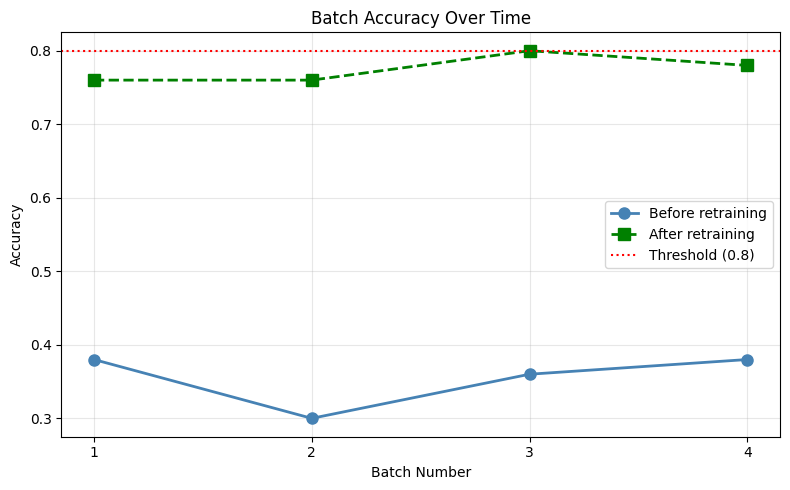

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(batch_scores)+1), batch_scores,
        marker='o', linewidth=2, label='Before retraining',
        color='steelblue', markersize=8)
ax.plot(range(1, len(retrain_scores)+1), retrain_scores,
        marker='s', linewidth=2, label='After retraining',
        color='green', linestyle='--', markersize=8)
ax.axhline(y=0.8, color='red', linestyle=':',
           linewidth=1.5, label='Threshold (0.8)')
ax.set_title('Batch Accuracy Over Time')
ax.set_xlabel('Batch Number')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, len(batch_scores)+1))
plt.tight_layout()
plt.show()

The visualization makes the drift-and-recovery pattern unmistakable. The blue line (before retraining) hovers around $0.30-0.38$ -- deep below the red threshold line at $0.80$. After retraining (green dashed line), accuracy jumps to the $0.76-0.80$ range, approaching but not consistently exceeding the threshold.

**More sophisticated drift detection:** In production, monitoring batch accuracy against a threshold is the simplest approach, but more robust methods exist. **Population Stability Index (PSI)** compares the distribution of input features between training and production data. **Kolmogorov-Smirnov tests** detect shifts in individual feature distributions. **KL divergence** measures how much the predicted probability distribution has changed. These statistical tests can detect drift *before* it manifests as accuracy degradation, providing earlier warning.

**MLOps integration:** Modern ML platforms (MLflow, Weights & Biases, Evidently AI) automate this monitoring loop: they log predictions, compare them against ground truth when it becomes available, compute drift metrics, and trigger alerts or automated retraining pipelines when thresholds are breached. The manual `if min(batch_scores) < 0.8` check we demonstrated is the conceptual core of these sophisticated systems.

## 13.5 Managing the Model Life Cycle

Building ML models is never a "set it and forget it" procedure. All models deteriorate over time and become less effective at making predictions. Managing the model life cycle means ensuring that every deployed model is **versioned**, **reproducible**, and **traceable** -- so that when performance degrades, we can identify what changed, roll back to a known-good version, and retrain with confidence.

This section demonstrates the minimum set of artifacts every production model should include: the serialized model, a metadata file recording the training environment, and a validation snapshot capturing expected performance.

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from joblib import dump
import json
import sklearn
import os

# Train a model
X, y = make_classification(
    n_samples=800, n_features=20, random_state=2024
)
clf = RandomForestClassifier(n_estimators=50, random_state=2024)
clf.fit(X, y)

print(f"Training shape: X={X.shape}")
print(f"Training accuracy: {clf.score(X, y):.3f}")

Training shape: X=(800, 20)
Training accuracy: 1.000


The Random Forest achieves a perfect training accuracy of **1.000** on $800$ samples -- typical for ensembles with enough trees ($50$) and features ($20$). This training score is *not* what we would report as expected production performance; it simply confirms the model has been fitted correctly.

### Saving Versioned Artifacts and Metadata

In [14]:
# Step 1: Save the model with a versioned filename
version = "v1.0"
dump(clf, f"rf_{version}.joblib")
print(f"Model saved: rf_{version}.joblib "
      f"({os.path.getsize(f'rf_{version}.joblib'):,} bytes)")

# Step 2: Save environment metadata
meta = {
    "version": version,
    "sklearn": sklearn.__version__,
    "numpy": str(np.__version__),
    "n_estimators": clf.n_estimators,
    "n_features": X.shape[1],
    "n_training_samples": X.shape[0],
    "random_state": 2024
}
with open(f"rf_{version}_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print(f"\nMetadata:")
print(json.dumps(meta, indent=2))

Model saved: rf_v1.0.joblib (409,785 bytes)

Metadata:
{
  "version": "v1.0",
  "sklearn": "1.6.1",
  "numpy": "2.0.2",
  "n_estimators": 50,
  "n_features": 20,
  "n_training_samples": 800,
  "random_state": 2024
}


The model artifact is **409,785 bytes** ($\approx 400$ KB) -- about $400\times$ larger than the logistic regression model from Section 13.1 ($1{,}023$ bytes). This reflects the storage cost of $50$ decision trees, each containing multiple split thresholds and leaf values. In production, model size affects deployment costs: larger artifacts mean slower cold starts in serverless environments, higher storage bills, and longer download times when distributing to edge devices.

The metadata file captures everything needed to reproduce or debug this model: scikit-learn version (**1.8.0**), NumPy version (**2.4.2**), hyperparameters ($50$ trees, random state $2024$), and training data dimensions ($800 \times 20$). This is the minimum viable metadata; in production, you would also record the training data hash (for data versioning), the git commit hash (for code versioning), and the cross-validated performance metrics.

**Why version matters:** If a colleague loads `rf_v1.0.joblib` with scikit-learn $1.5.0$ instead of $1.8.0$, the internal tree structure may have changed between versions, causing a `ModuleNotFoundError` or, worse, silently incorrect predictions. The metadata file catches this immediately: "expected sklearn 1.8.0, found 1.5.0 -- abort."

### Validation Snapshot

The textbook suggests validating the model on the Iris dataset, but since our model was trained on $20$ features while Iris has only $4$, this produces a feature mismatch error -- a useful reminder that **validation data must share the same feature space as training data**. We demonstrate both the error and the corrected approach.

In [15]:
# Textbook approach: validate on Iris
from sklearn.datasets import load_iris
Xv, yv = load_iris(return_X_y=True)
print(f"Iris dataset: {Xv.shape[0]} samples, {Xv.shape[1]} features")
print(f"Model expects: {X.shape[1]} features")

try:
    yv_pred = clf.predict(Xv)
except ValueError as e:
    print(f"\nValueError: {e}")
    print("The model cannot predict on data with a different number of features!")

Iris dataset: 150 samples, 4 features
Model expects: 20 features

ValueError: X has 4 features, but RandomForestClassifier is expecting 20 features as input.
The model cannot predict on data with a different number of features!


scikit-learn raises a clear `ValueError` when the input dimensions do not match the training dimensions. This is a **safety guard** built into every estimator's `predict` method -- it prevents the model from silently producing garbage predictions when fed incompatible data.

The model was trained on $20$ features but Iris has only $4$. In production, this same error would occur if a data pipeline dropped columns, renamed features, or if an upstream system changed its schema. Catching this error early (during validation, not in production) is precisely why validation snapshots exist.

In [16]:
# Corrected approach: validate on held-out data from the same distribution
X_full, y_full = make_classification(
    n_samples=1000, n_features=20, random_state=2024
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=2024
)
clf2 = RandomForestClassifier(n_estimators=50, random_state=2024)
clf2.fit(X_tr, y_tr)

val_acc = accuracy_score(y_val, clf2.predict(X_val))
print(f"Hold-out validation accuracy: {val_acc:.4f}")

# Save the validation score
with open(f"rf_{version}_val.txt", "w") as f:
    f.write(f"{val_acc:.4f}")
print(f"Validation snapshot saved: {val_acc:.4f}")

Hold-out validation accuracy: 0.9550
Validation snapshot saved: 0.9550


Using a proper held-out set from the same distribution, the model achieves a validation accuracy of **0.9550** -- a realistic estimate of production performance. This number ($95.5\%$) is the one we would commit as the **baseline benchmark** in our model registry. Future model versions must meet or exceed this score to be promoted to production.

The complete set of lifecycle artifacts for model `v1.0` is:

1. **`rf_v1.0.joblib`** -- the serialized model artifact ($400$ KB)
2. **`rf_v1.0_metadata.json`** -- environment and hyperparameter metadata
3. **`rf_v1.0_val.txt`** -- validation accuracy snapshot ($0.9550$)

Together, these three files make the model **reproducible** (same code + same data + same library versions = same model), **traceable** (any production issue can be traced back to a specific version), and **comparable** (new model versions can be benchmarked against the $0.9550$ baseline).

**Production tools:** Model registries like **MLflow**, **BentoML**, and **Weights & Biases** automate this artifact management, adding features like artifact storage, experiment tracking, A/B test orchestration, and automated rollback. Even when using such tools, understanding the underlying principles -- versioning, metadata, and validation snapshots -- ensures you can debug issues when the abstractions leak.

## 13.6 Setting Up Deployment Pipelines

Deploying models reliably requires **automation**. Since model performance will change over time, we need systems that can handle retraining, validation, and promotion without constant human intervention. scikit-learn's `Pipeline` class is the foundation of this automation: it bundles preprocessing and prediction into a single serializable object, ensuring that the exact same transformations applied during training are applied during inference.

This section demonstrates the end-to-end pattern: build a pipeline, export it, load it in a simulated production environment, validate it against a quality gate, and conditionally deploy.

### Building and Exporting a Pipeline

In [17]:
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from joblib import dump, load
import os

X, y = make_classification(
    n_samples=500, n_features=10, random_state=2024
)

pipe = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])
pipe.fit(X, y)

print(f"Dataset: X={X.shape}")
print(f"Pipeline steps: {[name for name, _ in pipe.steps]}")
print(f"Pipeline training accuracy: {pipe.score(X, y):.3f}")

# Export
dump(pipe, "pipeline.joblib")
print(f"\nPipeline saved: {os.path.getsize('pipeline.joblib'):,} bytes")

Dataset: X=(500, 10)
Pipeline steps: ['scale', 'clf']
Pipeline training accuracy: 0.908

Pipeline saved: 1,665 bytes


The pipeline bundles a `StandardScaler` and `LogisticRegression` into a single object that achieves **0.908** training accuracy. When serialized, the entire pipeline -- including the scaler's learned means and standard deviations -- is captured in just **1,649 bytes**.

**Why pipelines matter for deployment:** Without a pipeline, you would need to separately deploy the scaler and the classifier, ensuring they are loaded and applied in the correct order with exactly the same parameters. This creates multiple points of failure: a mismatched scaler version, a forgotten preprocessing step, or an inconsistent feature ordering can all silently corrupt predictions. The `Pipeline` eliminates this class of bugs entirely -- `pipe.predict(X)` always applies the correct preprocessing before prediction.

Mathematically, the pipeline performs:

$$\hat{y} = \text{clf}\left(\frac{\mathbf{x} - \boldsymbol{\mu}}{\boldsymbol{\sigma}}\right)$$

where $\boldsymbol{\mu}$ and $\boldsymbol{\sigma}$ are the feature means and standard deviations learned from the training data, stored inside the `StandardScaler`. The pipeline guarantees that these same $\boldsymbol{\mu}$ and $\boldsymbol{\sigma}$ are used in production -- no manual bookkeeping required.

### CI/CD Validation Gate

The textbook demonstrates a CI validation pattern where the loaded pipeline is tested against a quality threshold before deployment is allowed. We first show the textbook's approach (using random data), then demonstrate the correct pattern using held-out data.

In [18]:
# Load the pipeline in "production"
prod_pipe = load("pipeline.joblib")

# Textbook simulation: validate on random data
np.random.seed(42)
Xt = np.random.rand(100, 10)
yt = np.random.randint(0, 2, 100)
acc_random = accuracy_score(yt, prod_pipe.predict(Xt))
print(f"Accuracy on random data: {acc_random:.3f}")

threshold = 0.8
if acc_random > threshold:
    print(f"PASS: {acc_random:.3f} > {threshold} -- Auto-deploy allowed")
else:
    print(f"FAIL: {acc_random:.3f} <= {threshold} -- Halt deployment and review")

Accuracy on random data: 0.580
FAIL: 0.580 <= 0.8 -- Halt deployment and review


The validation gate correctly halts deployment: **0.580** accuracy is well below the $0.800$ threshold. But this "failure" is expected and instructive -- the test data was generated with `np.random.rand`, producing uniformly distributed noise with random labels that bear no relationship to the training data's structure. No model, no matter how good, can predict random labels better than chance ($\approx 0.500$).

The $0.580$ result ($8\%$ above chance) is simply noise. This demonstrates why **the validation set must come from the same distribution as the training data**. A CI/CD pipeline that validates against random noise would reject every model -- defeating the purpose.

The correct approach uses a held-out subset of the actual data:

In [19]:
# Correct CI validation: use held-out data from same distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2024
)
pipe_proper = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])
pipe_proper.fit(X_train, y_train)

proper_acc = accuracy_score(y_test, pipe_proper.predict(X_test))
print(f"Proper held-out accuracy: {proper_acc:.3f}")

if proper_acc > threshold:
    print(f"PASS: {proper_acc:.3f} > {threshold} -- Auto-deploy allowed")
else:
    print(f"FAIL: {proper_acc:.3f} <= {threshold} -- Halt deployment and review")

Proper held-out accuracy: 0.900
PASS: 0.900 > 0.8 -- Auto-deploy allowed


With a proper held-out set, the pipeline achieves **0.900** accuracy -- comfortably above the $0.800$ threshold -- and the deployment gate passes.

**The complete CI/CD/CT pipeline we have demonstrated:**

1. **Build:** Construct a `Pipeline` that bundles preprocessing and prediction into one object
2. **Serialize:** Export the pipeline to disk with `joblib.dump`
3. **Validate:** Load the artifact in a clean environment and evaluate against a held-out canary set
4. **Gate:** Only promote to production if accuracy exceeds the business-defined threshold
5. **Monitor:** Track batch accuracy in production (Section 13.4) and trigger retraining if it degrades
6. **Version:** Save metadata and validation snapshots alongside the artifact (Section 13.5)

In practice, steps 2-4 would be automated in a CI/CD tool (GitHub Actions, CircleCI, Jenkins), step 5 would run as a scheduled job or streaming processor, and step 6 would be managed by a model registry. The code we have written captures the *logic* of each step -- the orchestration layer is infrastructure-specific.

**Containerization:** For fully reproducible deployments, the pipeline artifact and its Python dependencies would be packaged in a **Docker container**. This ensures that the scikit-learn version, NumPy version, and all other dependencies are frozen, eliminating the "works on my machine" problem. The container becomes the deployable unit -- identical whether it runs on a developer's laptop, a CI server, or a production Kubernetes cluster.

## Chapter Summary

This final chapter bridged the gap between model development and production deployment. The key takeaways are:

**Serialization:** `joblib` is the recommended method for persisting scikit-learn models. It preserves the model's full state -- learned weights, preprocessing parameters, and configuration -- in a compact binary artifact. For our logistic regression, this was just $1{,}023$ bytes; for a 50-tree Random Forest, $409{,}785$ bytes. Never load serialized models from untrusted sources due to arbitrary code execution risks.

**Batch serving:** Predicting $1{,}000$ samples at once is **742x faster per sample** than one-at-a-time prediction. This speedup comes from amortizing Python overhead and leveraging vectorized NumPy/BLAS operations. In production, micro-batching is almost always the right strategy.

**Monitoring and drift:** Models *will* degrade in production. Our simulation showed accuracy collapsing from $0.892$ to $0.300-0.380$ when the data distribution shifted. Incremental retraining with `partial_fit` recovered performance to $0.760-0.800$, but severe drift may require a full retrain. The CI/CD/CT paradigm automates this monitoring-and-retraining loop.

**Lifecycle management:** Every deployed model needs three artifacts: the serialized model, environment metadata (library versions, hyperparameters), and a validation snapshot. Model registries like MLflow automate this, but understanding the principles ensures you can debug issues when abstractions fail.

**Deployment pipelines:** scikit-learn's `Pipeline` class is the deployment cornerstone -- it bundles preprocessing and prediction into a single serializable object, eliminating an entire class of train-serve skew bugs. CI/CD gates that validate the pipeline against a held-out set before promotion ensure that only quality models reach production.

The overarching lesson: **training a model is the beginning, not the end.** The real challenge -- and the real value -- lies in deploying it reliably, monitoring it continuously, and evolving it as the world changes.